**Fine-Tuning BERT on a Kaggle Dataset**


**Setup & Imports**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

C:\Users\shivaprasad\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


**Load Dataset**

In [2]:
data = pd.read_json(r"C:\Users\shivaprasad\Downloads\archive (14)\News_Category_Dataset_v3.json", lines=True)
data
print("Shape:", data.shape)
print(data.head())
print(data.columns)

Shape: (209527, 6)
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla K. Johnson, AP   
1  He was subdued by passengers and crew when he ...        Mary Papenfuss   
2  "Unt

**Select Required Columns**

In [3]:
data = data[['headline', 'category']]
data.columns = ['text', 'label']

print(data.head())

                                                text      label
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY
3  The Funniest Tweets From Parents This Week (Se...  PARENTING
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS


**Data Cleaning**

In [4]:
#Handling missing values
print(data.isnull().sum())

text     0
label    0
dtype: int64


**Basic EDA**

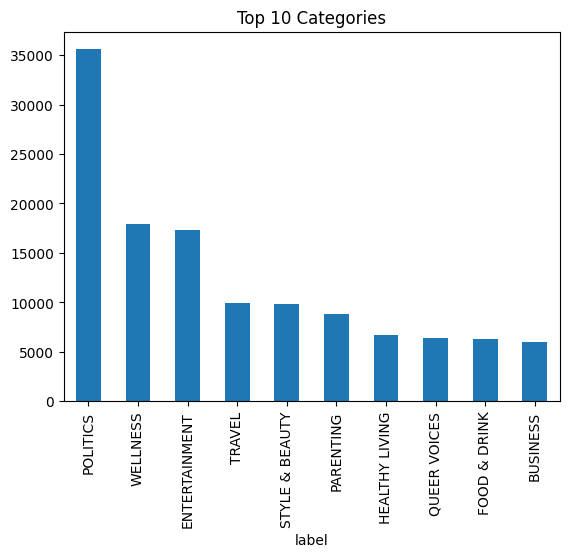

In [5]:
#Label distribution
data['label'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Categories")
plt.show()

**Reduce Classes**

In [6]:
top_categories = data['label'].value_counts().head(5).index
data = data[data['label'].isin(top_categories)]

In [7]:
#REDUCE DATA SIZE (VERY IMPORTANT)
data = data.groupby('label').head(1000)

print("Reduced dataset size:", data.shape)

Reduced dataset size: (5000, 2)


**Encode Labels**

In [8]:
label_map = {label: i for i, label in enumerate(data['label'].unique())}
data['label'] = data['label'].map(label_map)

print(label_map)

{'ENTERTAINMENT': 0, 'POLITICS': 1, 'WELLNESS': 2, 'STYLE & BEAUTY': 3, 'TRAVEL': 4}


**Text Cleaning**

In [9]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text

data['text'] = data['text'].apply(clean_text)

**Text Length EDA**

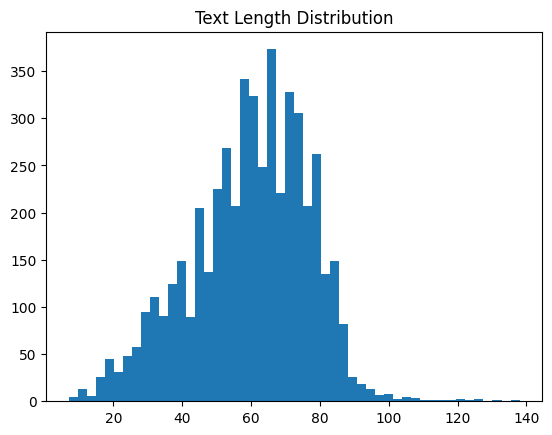

In [10]:
data['length'] = data['text'].apply(len)

plt.hist(data['length'], bins=50)
plt.title("Text Length Distribution")
plt.show()

**Train/Validation/Test Split**

In [11]:
train_data, temp_data = train_test_split(data, test_size=0.2, random_state=42)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(len(train_data), len(valid_data), len(test_data))

4000 500 500


In [12]:
train_dataset = Dataset.from_pandas(train_data.reset_index(drop=True))
valid_dataset = Dataset.from_pandas(valid_data.reset_index(drop=True))
test_dataset  = Dataset.from_pandas(test_data.reset_index(drop=True))

**Tokenization**

In [13]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

def tokenize(example):
    return tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)
test_dataset  = test_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

In [14]:
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
valid_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

**Model**

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(label_map)
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


**Metrics**

In [16]:
def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

**Model Training**

In [17]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    logging_steps=100
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    compute_metrics=compute_metrics
)

trainer.train()

C:\Users\shivaprasad\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,1.027955
200,0.586830
300,0.479229
400,0.422188
500,0.432166
600,0.161496
700,0.198733
800,0.203400
900,0.248751
1000,0.227498


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\shivaprasad\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1000, training_loss=0.39882454490661623, metrics={'train_runtime': 5643.2434, 'train_samples_per_second': 1.418, 'train_steps_per_second': 0.177, 'total_flos': 526236284928000.0, 'train_loss': 0.39882454490661623, 'epoch': 2.0})

**Evaluation**

In [18]:
import torch
import numpy as np
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Ensure your dataset has integer labels
# data['label'] should already be mapped using label_map

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# Create DataLoader
valid_dataloader = DataLoader(
    valid_dataset,  # your dataset processed with label_map
    batch_size=16,
    shuffle=False
)

all_preds = []
all_labels = []

with torch.no_grad():
    for batch in valid_dataloader:
        # Automatically get label key
        label_key = [k for k in batch.keys() if 'label' in k][0]

        labels = batch[label_key].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != label_key}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:\n", cm)

Accuracy: 0.8940
Precision: 0.8943
Recall: 0.8940
F1 Score: 0.8936
Confusion Matrix:
 [[101   5   0   4   2]
 [  8  90   0   0   2]
 [  1   0  85   6   4]
 [  3   1   7  74   5]
 [  1   1   3   0  97]]


**Confusion Matrix Label**

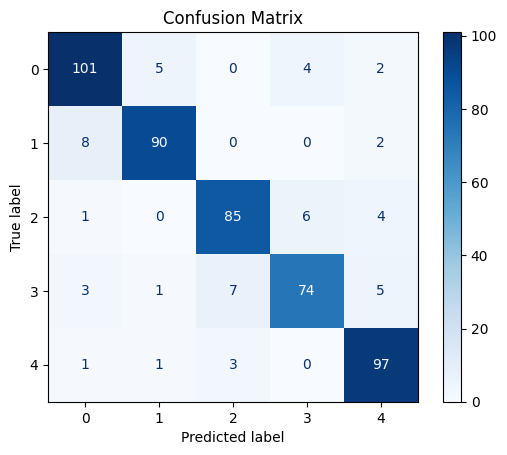

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

**EXPERIMENTS**

**Experiment1:Freeze BERT**

In [22]:
for param in model.bert.parameters():
    param.requires_grad = False

**Experiment 2: Fine-tune Last 2 Layers**

In [23]:
for param in model.bert.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

**Output Of Experiments**

In [24]:
for i, layer in enumerate(model.bert.encoder.layer):
    grad_flags = [p.requires_grad for p in layer.parameters()]
    print(f"Layer {i}: {all(grad_flags)}")

Layer 0: False
Layer 1: False
Layer 2: False
Layer 3: False
Layer 4: False
Layer 5: False
Layer 6: False
Layer 7: False
Layer 8: False
Layer 9: False
Layer 10: True
Layer 11: True
